In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    f1_score,
    confusion_matrix,
    precision_recall_curve,
    precision_score,
    recall_score,
    average_precision_score,
    brier_score_loss
)
from sklearn.calibration import calibration_curve

In [2]:
cwd = Path.cwd()
project_root = cwd.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
    print("Done!")

In [3]:
from credit_risk.features import FEATURES_DIR, load_features

2026-06-09 16:52:22.112 | INFO     | credit_risk.config:<module>:11 - PROJ_ROOT path is: /Users/ak007/SML/Credit-Risk-Default-Prediction-System


In [4]:
feature_splits = load_features(path=FEATURES_DIR)

2026-06-09 16:52:22.179 | INFO     | credit_risk.features:load_features:252 - Loading the processed features...
2026-06-09 16:52:22.564 | INFO     | credit_risk.features:load_features:259 - Loaded successfully!


In [5]:
X_train = feature_splits['train'][0].to_numpy()
y_train = feature_splits['train'][1].to_numpy().ravel()
X_val = feature_splits['val'][0].to_numpy()
y_val = feature_splits['val'][1].to_numpy().ravel()
X_test = feature_splits['test'][0].to_numpy()
y_test = feature_splits['test'][1].to_numpy().ravel()

In [6]:
lr_model = LogisticRegression()
lr_model.fit(X=X_train, y=y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [7]:
y_train_pred = lr_model.predict(X_train)
y_val_pred = lr_model.predict(X_val)

In [8]:
accuracy_score(y_true=y_train, y_pred=y_train_pred)

0.8337167036447359

In [9]:
f1_score(y_true=y_train, y_pred=y_train_pred)

0.03011226392660918

In [10]:
confusion_matrix(y_true=y_train, y_pred=y_train_pred)

array([[387344,   1103],
       [ 76392,   1203]])

In [11]:
precision_score(y_true=y_train, y_pred=y_train_pred)

0.5216825672159584

In [12]:
recall_score(y_true=y_train, y_pred=y_train_pred)

0.015503576261357047

In [13]:
print(feature_splits['train'][0].describe().T[['mean', 'std']].head(10))

                                     mean       std
num__loan_amnt               1.131887e-16  1.000001
num__funded_amnt             7.415812e-17  1.000001
num__funded_amnt_inv        -1.561224e-17  1.000001
num__int_rate               -1.600254e-16  1.000001
num__installment            -1.014795e-16  1.000001
num__annual_inc              1.385586e-16  1.000001
num__dti                     9.367342e-17  1.000001
num__delinq_2yrs             6.244894e-17  1.000001
num__inq_last_6mths          1.170918e-17  1.000001
num__mths_since_last_delinq  1.346555e-16  1.000001


In [14]:
feature_splits['train'][1].value_counts(normalize=True)

target
0         0.833502
1         0.166498
Name: proportion, dtype: float64

In [18]:
y_train_proba = lr_model.predict_proba(X_train)[:, 1]  # probability of class 1 (default)
y_val_proba   = lr_model.predict_proba(X_val)[:, 1]

print(roc_auc_score(y_true=y_train, y_score=y_train_proba))
print(roc_auc_score(y_true=y_val,   y_score=y_val_proba))

0.7014660152142602
0.7096220470170289


In [19]:
metrics_on = lambda y_true, y_pred, y_proba: {
    "accuracy": accuracy_score(y_true, y_pred),
    "roc_auc":  roc_auc_score(y_true, y_proba),
    "f1":       f1_score(y_true, y_pred),
    "precision": precision_score(y_true, y_pred),
    "recall":   recall_score(y_true, y_pred),
}

print("TRAIN:", metrics_on(y_train, y_train_pred, y_train_proba))
print("VAL:  ", metrics_on(y_val,   y_val_pred,   y_val_proba))

TRAIN: {'accuracy': 0.8337167036447359, 'roc_auc': 0.7014660152142602, 'f1': 0.03011226392660918, 'precision': 0.5216825672159584, 'recall': 0.015503576261357047}
VAL:   {'accuracy': 0.8171340586953004, 'roc_auc': 0.7096220470170289, 'f1': 0.04423050611341219, 'precision': 0.5497835497835498, 'recall': 0.023042131591565904}


In [20]:
w_lr_model =  LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42,
)

In [21]:
w_lr_model.fit(X=X_train, y=y_train)

/Users/ak007/SML/Credit-Risk-Default-Prediction-System/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [22]:
y_train_pred = w_lr_model.predict(X_train)
y_val_pred = w_lr_model.predict(X_val)
y_test_pred = w_lr_model.predict(X_test)

In [23]:
y_train_proba = w_lr_model.predict_proba(X_train)[:, 1]  # probability of class 1 (default)
y_val_proba   = w_lr_model.predict_proba(X_val)[:, 1]
y_test_proba  = w_lr_model.predict_proba(X_test)[:, 1]

print(roc_auc_score(y_true=y_train, y_score=y_train_proba))
print(roc_auc_score(y_true=y_val,   y_score=y_val_proba))
print(roc_auc_score(y_true=y_test,  y_score=y_test_proba))

0.7013744107194275
0.7096204407501892
0.696727572911196


In [24]:
metrics_on = lambda y_true, y_pred, y_proba: {
    "accuracy": accuracy_score(y_true, y_pred),
    "roc_auc":  roc_auc_score(y_true, y_proba),
    "f1":       f1_score(y_true, y_pred),
    "precision": precision_score(y_true, y_pred),
    "recall":   recall_score(y_true, y_pred),
}

print("TRAIN:", metrics_on(y_train, y_train_pred, y_train_proba))
print("VAL:  ", metrics_on(y_val,   y_val_pred,   y_val_proba))

TRAIN: {'accuracy': 0.6338613258032538, 'roc_auc': 0.7013744107194275, 'f1': 0.37670402244268786, 'precision': 0.26285498728137474, 'recall': 0.6645273535665958}
VAL:   {'accuracy': 0.6308792872033584, 'roc_auc': 0.7096204407501892, 'f1': 0.40489418192421617, 'precision': 0.2875899996184725, 'recall': 0.683812189780076}


In [27]:
pr_auc_train= average_precision_score(y_train, y_train_proba)
pr_auc_val= average_precision_score(y_val, y_val_proba)

In [28]:
pr_auc_train, pr_auc_val

(0.31202019684710663, 0.3460863987717971)

In [33]:
precisions, recalls, thresholds = precision_recall_curve(y_val, y_val_proba)
# Find the highest recall achievable at precision >= 0.80
mask = precisions >= 0.80
if mask.any():
    recall_at_high_precision = recalls[mask].max()
else:
    recall_at_high_precision = 0.0  # can't reach precision 0.80

print(f"Recall at precision ≥ 0.80: {recall_at_high_precision:.3f}")

Recall at precision ≥ 0.80: 0.000


In [32]:
brier_val = brier_score_loss(y_val, y_val_proba)
print(f"Brier score: {brier_val:.4f}")

Brier score: 0.2216


In [34]:
y_train_proba

array([0.26058834, 0.52420036, 0.58342915, ..., 0.60798926, 0.58571803,
       0.54797754], shape=(466042,))

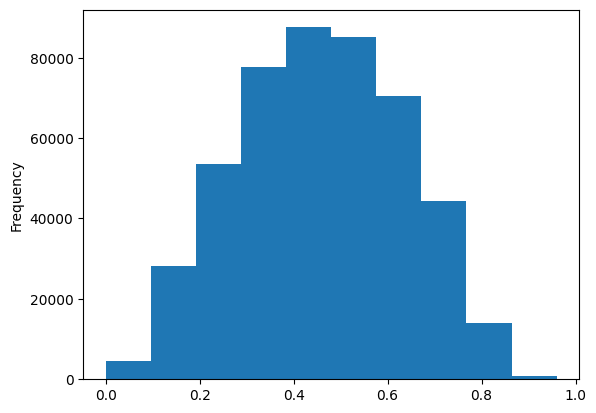

In [37]:
pd.Series(y_train_proba).plot.hist(bins=10);

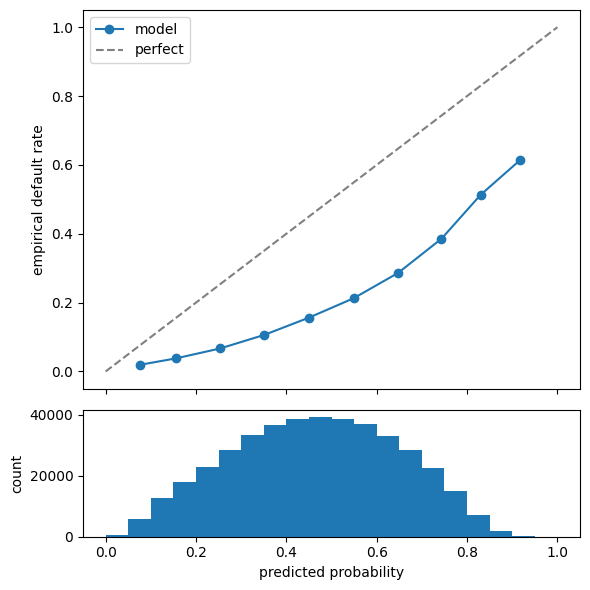

In [41]:
prob_true, prob_pred = calibration_curve(y_val, y_val_proba, n_bins=10)

fig, (ax1, ax2) = plt.subplots(
    2, 1, sharex=True, height_ratios=[3, 1], figsize=(6, 6)
)

# top: reliability curve
ax1.plot(prob_pred, prob_true, marker="o", label="model")
ax1.plot([0, 1], [0, 1], "--", color="gray", label="perfect")
ax1.set_ylabel("empirical default rate")
ax1.legend()

# bottom: where the predicted mass actually sits
ax2.hist(y_val_proba, bins=20, range=(0, 1))
ax2.set_xlabel("predicted probability")
ax2.set_ylabel("count")

plt.tight_layout()
plt.show()

In [42]:
prob_pred

array([0.07609697, 0.15569625, 0.25347011, 0.35151383, 0.45035684,
       0.54920365, 0.64748522, 0.74333966, 0.83038056, 0.91660155])

In [43]:
prob_true

array([0.01937084, 0.03806835, 0.06682638, 0.10638419, 0.15653813,
       0.21287437, 0.28634476, 0.38549049, 0.5135628 , 0.61306533])

In [7]:
lr_model = LogisticRegression()
lr_model.fit(X=X_train, y=y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [8]:
y_train_pred = lr_model.predict(X_train)
y_val_pred = lr_model.predict(X_val)

In [9]:
y_train_proba = lr_model.predict_proba(X_train)[:, 1]
y_val_proba   = lr_model.predict_proba(X_val)[:, 1]
y_test_proba = lr_model.predict_proba(X_test)[:, 1]

print(roc_auc_score(y_true=y_train, y_score=y_train_proba))
print(roc_auc_score(y_true=y_val,   y_score=y_val_proba))

0.7014660152142602
0.7096220470170289


In [20]:
metrics_on = lambda y_true, y_pred, y_proba: {
    "accuracy": accuracy_score(y_true, y_pred),
    "roc_auc":  roc_auc_score(y_true, y_proba),
    "f1":       f1_score(y_true, y_pred),
    "precision": precision_score(y_true, y_pred),
    "recall":   recall_score(y_true, y_pred),
}

print("TRAIN:", metrics_on(y_train, y_train_pred, y_train_proba))
print("VAL:  ", metrics_on(y_val,   y_val_pred,   y_val_proba))

TRAIN: {'accuracy': 0.8337167036447359, 'roc_auc': 0.7014660152142602, 'f1': 0.03011226392660918, 'precision': 0.5216825672159584, 'recall': 0.015503576261357047}
VAL:   {'accuracy': 0.8171340586953004, 'roc_auc': 0.7096220470170289, 'f1': 0.04423050611341219, 'precision': 0.5497835497835498, 'recall': 0.023042131591565904}


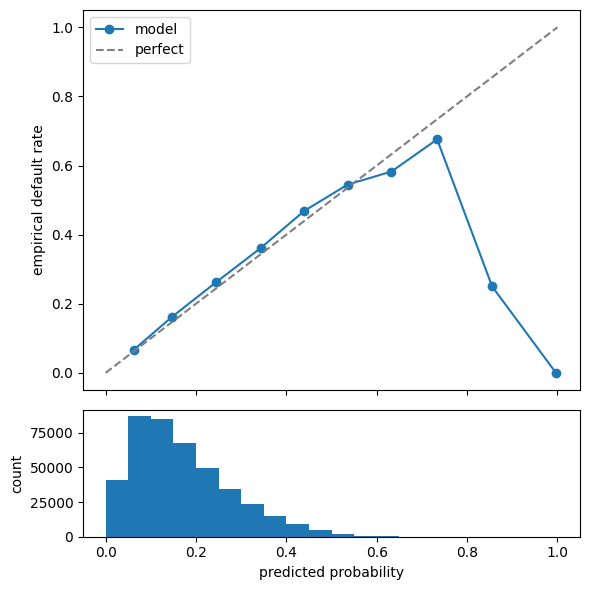

In [21]:
prob_true, prob_pred = calibration_curve(y_val, y_val_proba, n_bins=10)

fig, (ax1, ax2) = plt.subplots(
    2, 1, sharex=True, height_ratios=[3, 1], figsize=(6, 6)
)

# top: reliability curve
ax1.plot(prob_pred, prob_true, marker="o", label="model")
ax1.plot([0, 1], [0, 1], "--", color="gray", label="perfect")
ax1.set_ylabel("empirical default rate")
ax1.legend()

# bottom: where the predicted mass actually sits
ax2.hist(y_val_proba, bins=20, range=(0, 1))
ax2.set_xlabel("predicted probability")
ax2.set_ylabel("count")

plt.tight_layout()
plt.show()

In [22]:
from sklearn.metrics import brier_score_loss
print(brier_score_loss(y_val, y_val_proba))
print((y_val_proba > 0.8).sum(), y_val[y_val_proba > 0.8].mean())

0.13725236569070684
7 0.14285714285714285


In [23]:
pr_auc_train= average_precision_score(y_train, y_train_proba)
pr_auc_val= average_precision_score(y_val, y_val_proba)

In [24]:
pr_auc_train, pr_auc_val

(0.31284769572861715, 0.34675236074186605)

In [25]:
import numpy as np

fn_cost = 9000   
fp_cost = 2000   

thresholds = np.linspace(0.01, 0.99, 99)
costs = []
for t in thresholds:
    preds = (y_val_proba >= t).astype(int)
    fn = ((preds == 0) & (y_val == 1)).sum()
    fp = ((preds == 1) & (y_val == 0)).sum()
    costs.append(fn * fn_cost + fp * fp_cost)

best_t = thresholds[np.argmin(costs)]

In [26]:
best_t

np.float64(0.17)

In [27]:
preds = (y_val_proba >= best_t).astype(int)

print(f"threshold: {best_t:.3f}")
print(f"precision: {precision_score(y_val, preds):.3f}")
print(f"recall:    {recall_score(y_val, preds):.3f}")
print(f"confusion matrix:\n{confusion_matrix(y_val, preds)}")

threshold: 0.170
precision: 0.291
recall:    0.670
confusion matrix:
[[217178 125863]
 [ 25485  51678]]


In [30]:
preds_test = (y_test_proba >= best_t).astype(int)
print(f"precision: {precision_score(y_test, preds_test):.3f}")
print(f"recall:    {recall_score(y_test, preds_test):.3f}")
print(f"confusion matrix:\n{confusion_matrix(y_test, preds_test)}")

precision: 0.271
recall:    0.627
confusion matrix:
[[236150 122764]
 [ 27133  45665]]


In [33]:
lr_model.coef_[0]

array([ 2.40988612e-01,  3.61685791e-01, -6.14785881e-01,  7.13127501e-02,
        1.43487601e-01, -1.64760974e-01,  1.33010984e-01,  4.41250124e-02,
        7.50608697e-02, -5.95442509e-03,  2.85024791e-02, -3.49666503e-02,
        3.24494824e-02,  6.84773734e-03,  1.20356066e-02, -1.04222508e-01,
        6.26697328e-03, -5.17224473e-05, -4.83849492e-03, -1.30551971e-03,
        6.43189668e-02, -6.68915562e-02,  1.34909895e-01, -5.76081275e-02,
        8.63839606e-02, -4.11777875e-02, -1.20360854e-02, -2.05298929e-03,
        1.75620578e-03, -9.68117850e-02,  1.85915209e-02, -2.60595304e-02,
       -2.26361802e-02, -6.10577738e-02, -5.57269475e-03, -3.10809896e-04,
       -2.67803747e-03,  1.91736691e-02, -2.66817488e-02, -3.36156845e-02,
        1.94499996e-02,  6.53563780e-02,  8.62781879e-03, -1.16419253e-02,
       -2.68439155e-02,  8.49966743e-02,  3.27981260e-02, -2.56996702e-03,
        5.48073826e-03, -1.83711177e-03,  2.59606716e-02,  5.14492800e-02,
        6.60035124e-02, -

In [36]:
# let's check which features were assigned important in the model
coefs = pd.Series(lr_model.coef_[0], index=feature_splits['train'][0].columns.to_list()).sort_values(ascending=False)

In [41]:
np.exp(coefs.head(10))

cat__purpose_small_business    1.561257
num__funded_amnt               1.435748
cat__emp_length_missing        1.353456
num__loan_amnt                 1.272507
cat__addr_state_MS             1.242174
cat__addr_state_NV             1.200107
cat__addr_state_AR             1.185301
cat__addr_state_AL             1.176851
cat__addr_state_OK             1.174069
cat__grade_G                   1.168801
dtype: float64

In [42]:
np.exp(coefs.tail(10))

cat__addr_state_KS      0.779720
cat__grade_B            0.759647
cat__addr_state_DC      0.734534
cat__addr_state_NH      0.732227
cat__addr_state_WV      0.708251
cat__purpose_wedding    0.684705
cat__sub_grade_A1       0.633433
cat__term_ 36 months    0.579083
num__funded_amnt_inv    0.540757
cat__grade_A            0.529796
dtype: float64

In [10]:
from credit_risk.evaluation import tune_threshold, compute_metrics

In [11]:
best_t = tune_threshold(y_true=y_val, y_proba=y_val_proba, fn_cost=10000, fp_cost=2000)

In [12]:
metrics = compute_metrics(y_true=y_val, y_proba=y_val_proba, threshold=best_t)

In [13]:
metrics

{'ROC-AUC': 0.7096220470170289,
 'PR-AUC': 0.34675236074186605,
 'brier_score': 0.13725236569070684,
 'precision': 0.27505798221878625,
 'recall': 0.7377369983022951,
 'confusion_matrix': array([[193007, 150034],
        [ 20237,  56926]]),
 'accuracy': 0.5947896735871149,
 'f1score': 0.400713775371934}

In [14]:
type(lr_model)

sklearn.linear_model._logistic.LogisticRegression